# Tekken 8 Win Predictor — Data Exploration

This notebook loads the monthly replay CSVs collected from the Wavu Wank API and produces visualizations to understand the data before training.

**What we are looking for:**
- Class balance (winner p1 vs p2 should be ~50/50)
- Which characters are well-represented vs sparse
- Whether Glicko2 rating and rank are actually predictive of wins
- Whether player history features are viable (need players with 20+ games)

In [1]:
!pip install -q pandas numpy matplotlib seaborn

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── Colab: mount Drive and point DATA_DIR at your folder ──────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = Path('/content/drive/MyDrive/tekken-data')
# ──────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

# Change this path to wherever your CSVs live
DATA_DIR = Path('../data')

In [3]:
CHAR_NAMES = {
    0: 'Paul',       1: 'Law',        2: 'King',       3: 'Yoshimitsu',
    4: 'Hwoarang',   5: 'Xiaoyu',     6: 'Jin',        7: 'Bryan',
    8: 'Kazuya',     9: 'Steve',     10: 'Jack-8',    11: 'Asuka',
   12: 'Devil Jin', 13: 'Feng',      14: 'Lili',      15: 'Dragunov',
   16: 'Leo',       17: 'Lars',      18: 'Alisa',     19: 'Claudio',
   20: 'Shaheen',   21: 'Nina',      22: 'Lee',       23: 'Kuma',
   24: 'Panda',     25: 'Zafina',    26: 'Leroy',     27: 'Jun',
   28: 'Reina',     29: 'Azucena',   30: 'Victor',    31: 'Raven',
   32: 'Azazel',    33: 'Eddy',      34: 'Lidia',     35: 'Heihachi',
   36: 'Clive',     37: 'Anna',      38: 'Armor King',39: 'Mairy Zo',
}

RANK_NAMES = {
     1: 'Beginner',      2: '1st Dan',       3: '2nd Dan',      4: 'Fighter',
     5: 'Strategist',    6: 'Combatant',      7: 'Brawler',      8: 'Ranger',
     9: 'Cavalry',      10: 'Warrior',       11: 'Assailant',   12: 'Dominator',
    13: 'Vanquisher',   14: 'Destroyer',     15: 'Eliminator',
    16: 'Garyu',        17: 'Shinryu',       18: 'Tenryu',
    19: 'Mighty Ruler', 20: 'Flame Ruler',   21: 'Battle Ruler',
    22: 'Fujin',        23: 'Raijin',        24: 'Kishin',      25: 'Bushin',
    26: 'Tekken King',  27: 'Tekken Emperor',28: 'Tekken God',
    29: 'TG Supreme',   30: 'God of Destruction',
}

## 1 — Load Data

In [5]:
csv_files = sorted(DATA_DIR.glob('replays_*.csv'))
print(f'Found {len(csv_files)} CSV files:')

dfs = []
for f in csv_files:
    tmp = pd.read_csv(f)
    tmp['month'] = f.stem.replace('replays_', '')
    dfs.append(tmp)
    print(f'  {f.name}: {len(tmp):,} records')

df = pd.concat(dfs, ignore_index=True)
df['battle_at'] = pd.to_datetime(df['battle_at'], unit='s', utc=True)

print(f'\nTotal: {len(df):,} records')
print(f'Date range: {df["battle_at"].min().date()} → {df["battle_at"].max().date()}')

Found 6 CSV files:
  replays_2025_12.csv: 504,071 records
  replays_2026_01.csv: 500,595 records
  replays_2026_02.csv: 504,456 records
  replays_2026_03.csv: 501,954 records
  replays_2026_04.csv: 502,846 records
  replays_2026_05.csv: 503,664 records

Total: 3,017,586 records
Date range: 2025-12-31 → 2026-05-31


In [6]:
nullable = ['p1_area_id', 'p2_area_id', 'p1_region_id', 'p2_region_id', 'p1_lang', 'p2_lang']
null_pct = (df[nullable].isnull().mean() * 100).round(1).sort_values(ascending=False)
print('Null rates for optional fields:')
print(null_pct.to_string())

Null rates for optional fields:
p1_area_id      6.5
p2_area_id      6.5
p1_region_id    6.5
p2_region_id    6.5
p1_lang         6.5
p2_lang         6.5


## 2 — Data Volume & Coverage

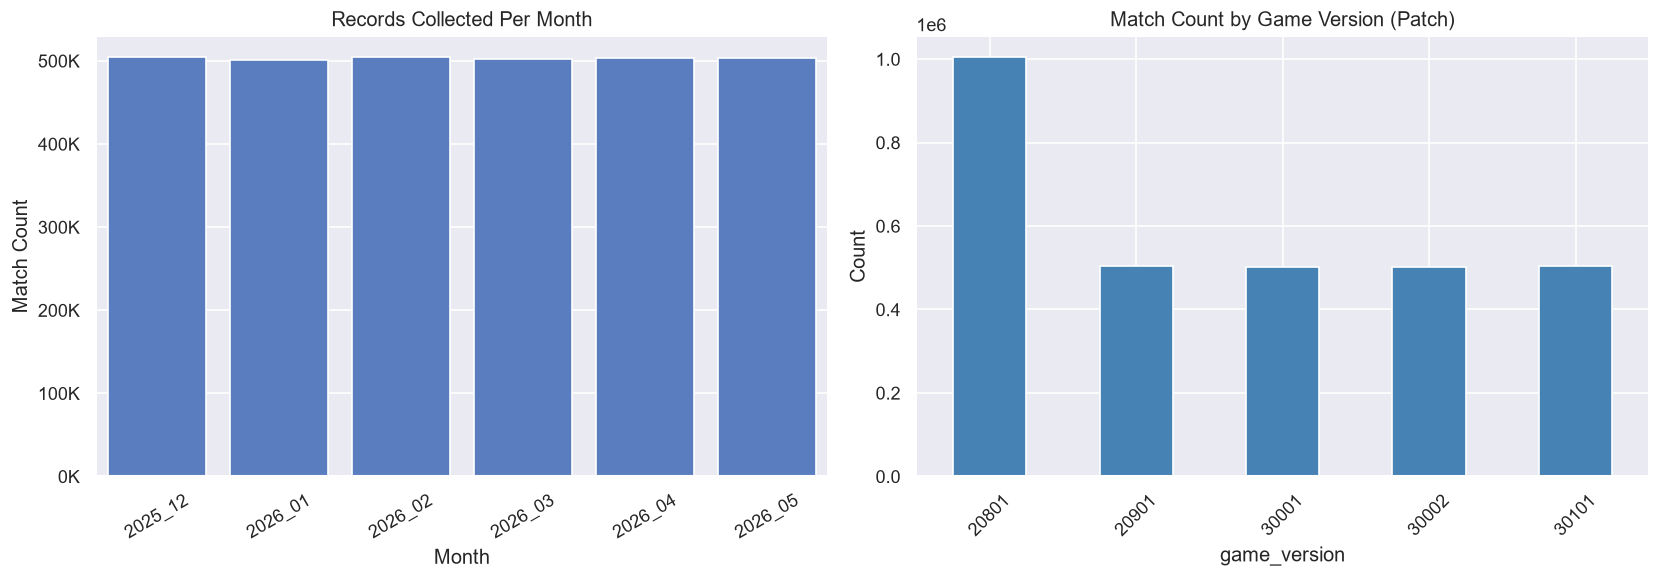

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly = df.groupby('month').size().reset_index(name='count')
sns.barplot(data=monthly, x='month', y='count', ax=axes[0])
axes[0].set_title('Records Collected Per Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Match Count')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.setp(axes[0].get_xticklabels(), rotation=30)

df['game_version'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Match Count by Game Version (Patch)')
axes[1].set_xlabel('game_version')
axes[1].set_ylabel('Count')
plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

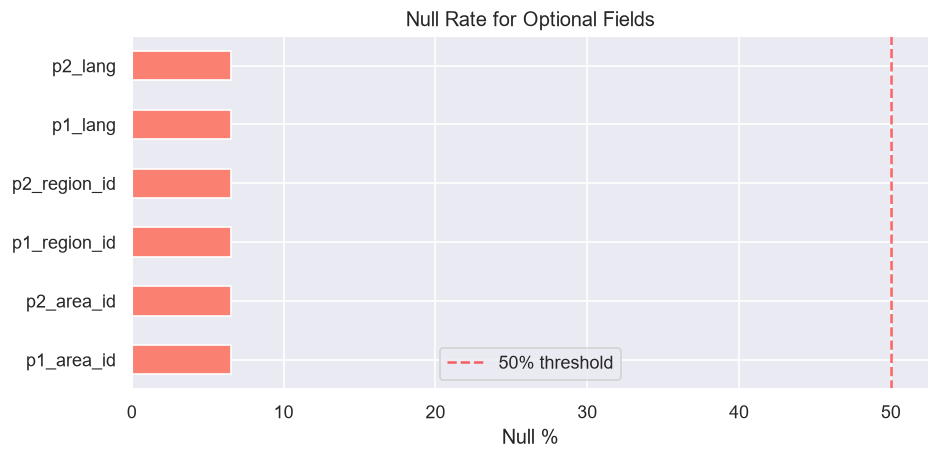

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
null_pct.sort_values().plot(kind='barh', ax=ax, color='salmon')
ax.axvline(50, color='red', linestyle='--', alpha=0.6, label='50% threshold')
ax.set_title('Null Rate for Optional Fields')
ax.set_xlabel('Null %')
ax.legend()
plt.tight_layout()
plt.show()

## 3 — Match Outcome Balance

**What to look for:** Should be very close to 50/50. If P1 wins significantly more, there may be a systematic bias in how the API orders players (e.g. higher-ranked player always listed as P1).

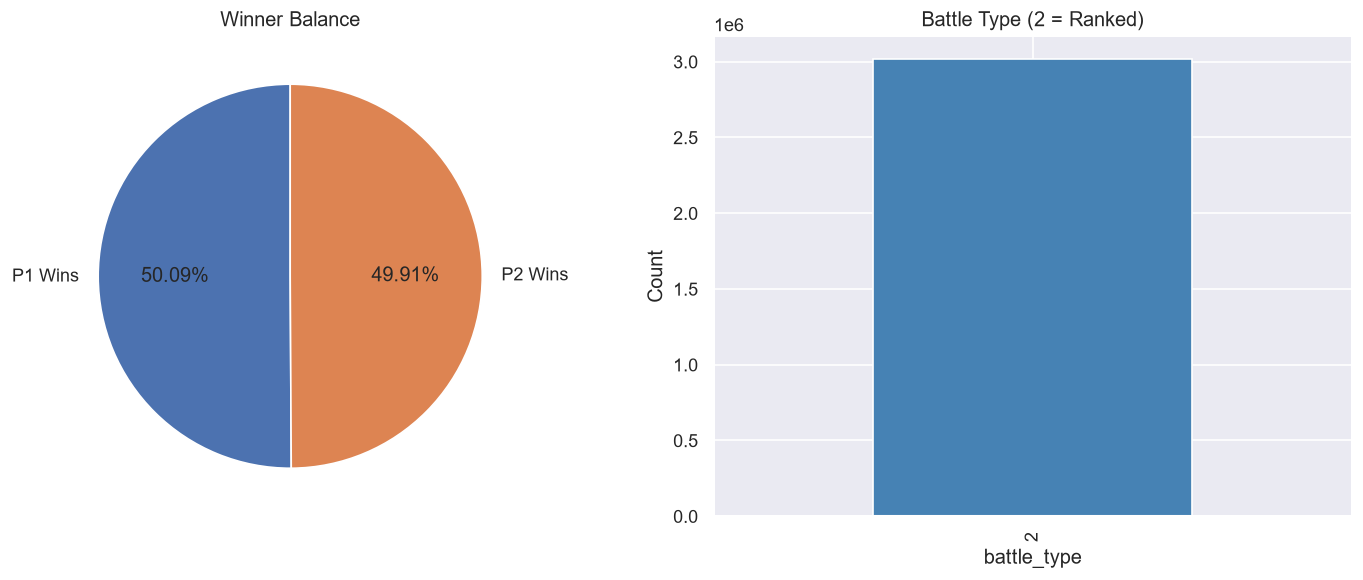

P1 wins : 1,511,231 (50.09%)
P2 wins : 1,505,964 (49.91%)
Invalid/null winner values: 391 rows (excluded from chart)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Filter to only valid winner values (1 or 2) before plotting
winner_counts = df[df['winner'].isin([1, 2])]['winner'].value_counts().sort_index()

axes[0].pie(
    winner_counts,
    labels=[f'P{i} Wins' for i in winner_counts.index],
    autopct='%1.2f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452']
)
axes[0].set_title('Winner Balance')

df['battle_type'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Battle Type (2 = Ranked)')
axes[1].set_xlabel('battle_type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

p1w   = winner_counts.get(1, 0)
p2w   = winner_counts.get(2, 0)
total = p1w + p2w
invalid = len(df) - total
print(f'P1 wins : {p1w:,} ({p1w/total*100:.2f}%)')
print(f'P2 wins : {p2w:,} ({p2w/total*100:.2f}%)')
if invalid:
    print(f'Invalid/null winner values: {invalid:,} rows (excluded from chart)')

## 4 — Character Analysis

**What to look for:**
- Characters with very few appearances will produce weak embeddings
- Win rates outside 45–55% indicate strong tier-list signal the model needs to capture

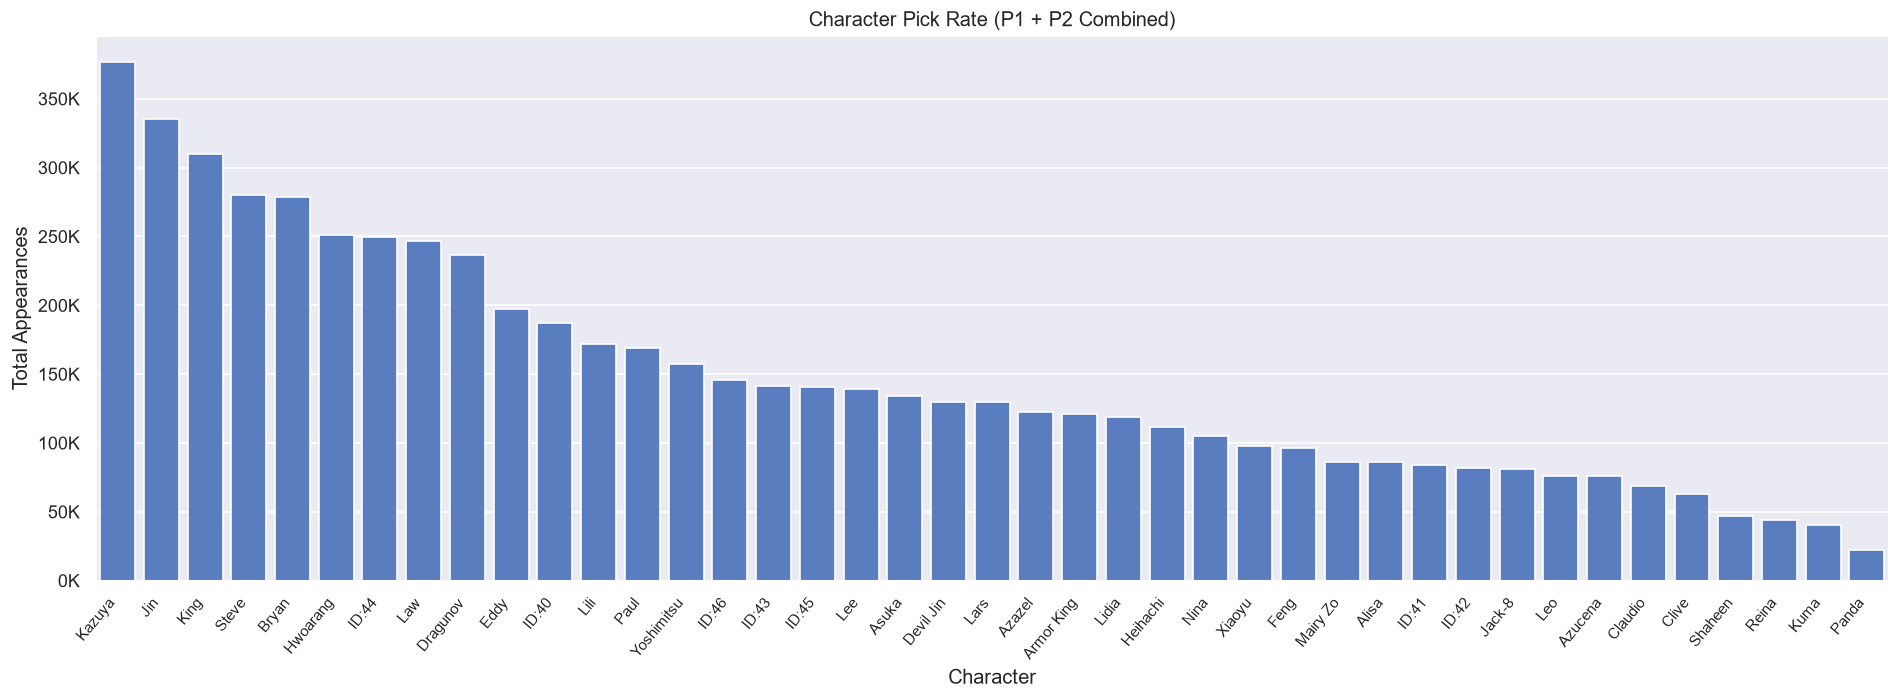

All characters have sufficient representation.


In [10]:
all_chars = pd.concat([df['p1_chara_id'], df['p2_chara_id']])
char_counts = all_chars.value_counts().reset_index()
char_counts.columns = ['chara_id', 'count']
char_counts['name'] = char_counts['chara_id'].map(CHAR_NAMES).fillna('ID:' + char_counts['chara_id'].astype(str))
char_counts = char_counts.sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=char_counts, x='name', y='count', ax=ax)
ax.set_title('Character Pick Rate (P1 + P2 Combined)')
ax.set_xlabel('Character')
ax.set_ylabel('Total Appearances')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.xticks(rotation=50, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

sparse = char_counts[char_counts['count'] < 1000]
if not sparse.empty:
    print('Characters with <1,000 appearances:')
    print(sparse[['name', 'count']].to_string(index=False))
else:
    print('All characters have sufficient representation.')

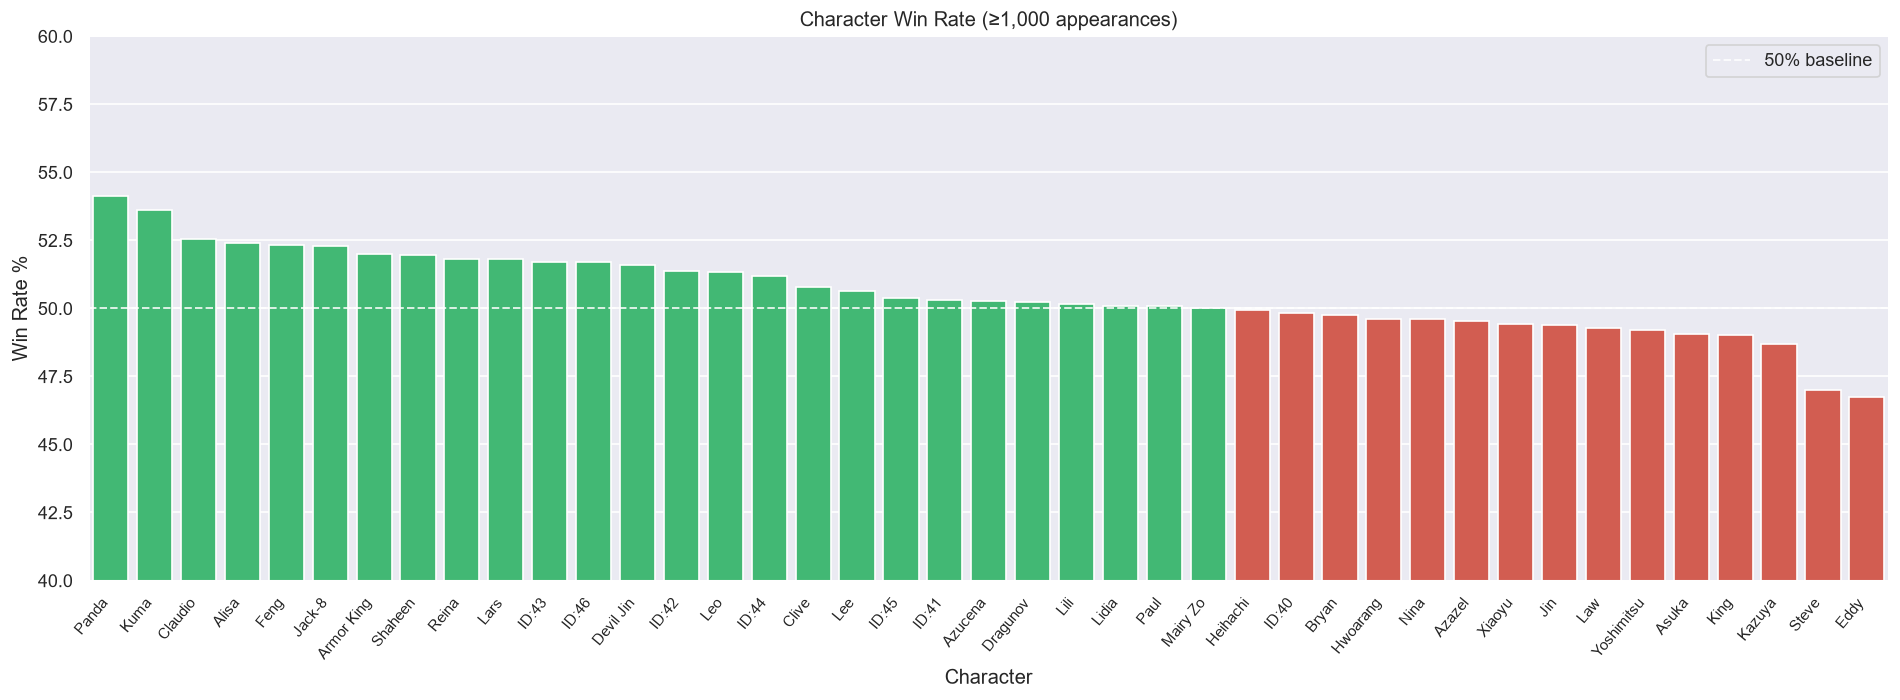

In [11]:
p1_wins   = df[df['winner'] == 1]['p1_chara_id'].value_counts()
p2_wins   = df[df['winner'] == 2]['p2_chara_id'].value_counts()
char_wins  = p1_wins.add(p2_wins, fill_value=0)
char_total = all_chars.value_counts()

char_wr = (char_wins / char_total * 100).reset_index()
char_wr.columns = ['chara_id', 'win_rate']
char_wr['name']  = char_wr['chara_id'].map(CHAR_NAMES).fillna('ID:' + char_wr['chara_id'].astype(str))
char_wr['total'] = char_wr['chara_id'].map(char_total)
char_wr = char_wr[char_wr['total'] >= 1000].sort_values('win_rate', ascending=False)

colors = ['#2ecc71' if w >= 50 else '#e74c3c' for w in char_wr['win_rate']]

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=char_wr, x='name', y='win_rate', palette=colors, ax=ax)
ax.axhline(50, color='white', linestyle='--', linewidth=1.2, alpha=0.8, label='50% baseline')
ax.set_title('Character Win Rate (≥1,000 appearances)')
ax.set_xlabel('Character')
ax.set_ylabel('Win Rate %')
ax.set_ylim(40, 60)
ax.legend()
plt.xticks(rotation=50, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

## 5 — Player Skill Distribution

**What to look for:**
- Rank distribution is typically right-skewed (most players are mid-rank)
- Glicko2 rating should form a bell curve — wide spread = strong predictive feature
- P1 and P2 rating curves should nearly overlap (no systematic ordering bias)

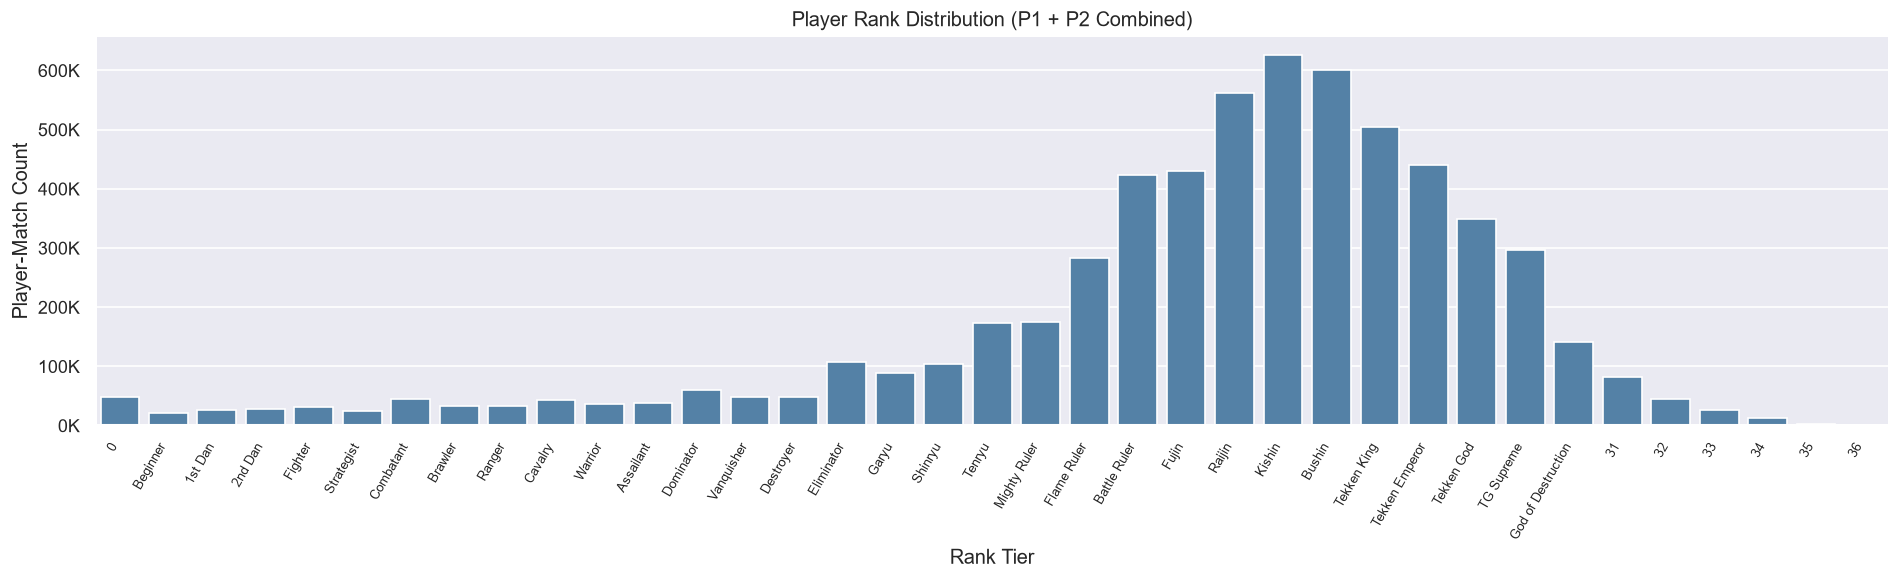

In [12]:
all_ranks = pd.concat([df['p1_rank'], df['p2_rank']]).dropna().astype(int)
rank_counts = all_ranks.value_counts().sort_index().reset_index()
rank_counts.columns = ['rank_id', 'count']
rank_counts['label'] = rank_counts['rank_id'].map(RANK_NAMES).fillna(rank_counts['rank_id'].astype(str))

fig, ax = plt.subplots(figsize=(16, 5))
sns.barplot(data=rank_counts, x='label', y='count', ax=ax, color='steelblue')
ax.set_title('Player Rank Distribution (P1 + P2 Combined)')
ax.set_xlabel('Rank Tier')
ax.set_ylabel('Player-Match Count')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

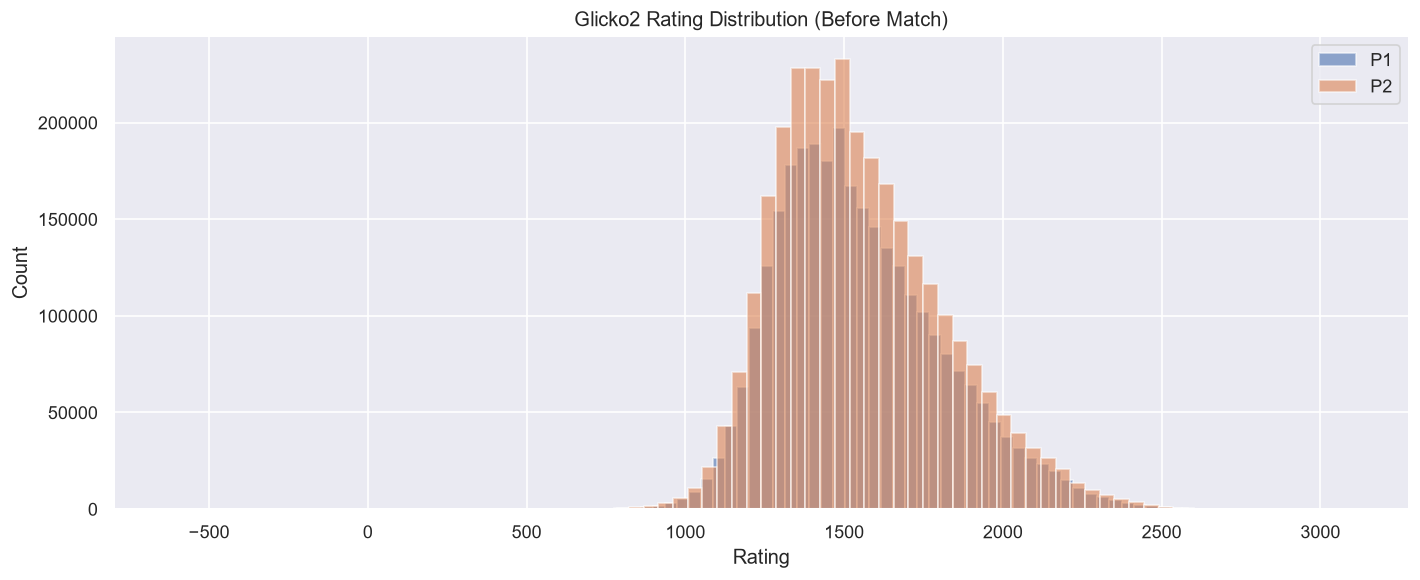

Rating summary stats:
count    6035172.0
mean        1550.2
std          261.6
min         -615.0
25%         1358.0
50%         1510.0
75%         1711.0
max         3093.0


In [13]:
fig, ax = plt.subplots()
df['p1_rating_before'].dropna().hist(bins=80, alpha=0.6, label='P1', ax=ax, color='#4C72B0')
df['p2_rating_before'].dropna().hist(bins=80, alpha=0.6, label='P2', ax=ax, color='#DD8452')
ax.set_title('Glicko2 Rating Distribution (Before Match)')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

combined_ratings = pd.concat([df['p1_rating_before'], df['p2_rating_before']]).dropna()
print('Rating summary stats:')
print(combined_ratings.describe().round(1).to_string())

## 6 — Key Signal Checks: Does Rating/Rank Actually Predict Wins?

**What to look for:**
- Both curves should form an S-shape through 50% at diff=0
- Steep slope = strong predictive signal. Flat line = weak feature

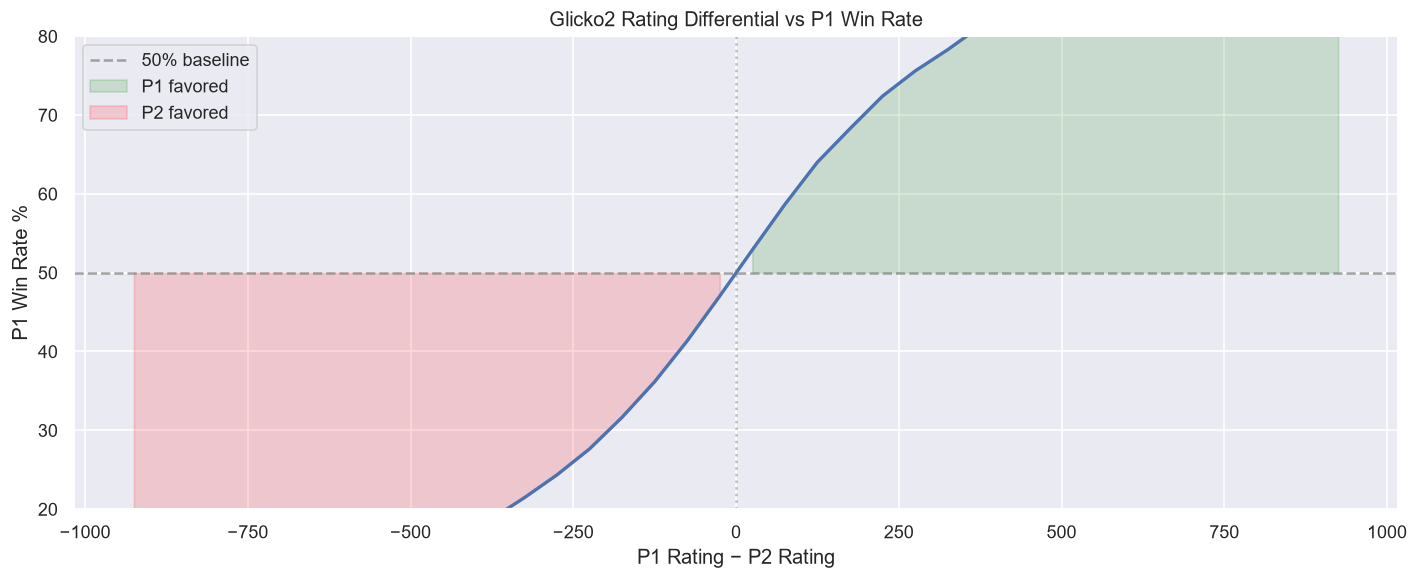

In [14]:
df['p1_won']      = (df['winner'] == 1).astype(int)
df['rating_diff'] = df['p1_rating_before'] - df['p2_rating_before']

df['rating_diff_bin'] = pd.cut(df['rating_diff'], bins=range(-1500, 1550, 50), right=False)
rating_signal = (
    df.groupby('rating_diff_bin', observed=True)['p1_won']
    .agg(['mean', 'count'])
    .reset_index()
)
rating_signal = rating_signal[rating_signal['count'] >= 200]
rating_signal['bin_center'] = rating_signal['rating_diff_bin'].apply(lambda x: x.mid)
rating_signal['win_pct']    = rating_signal['mean'] * 100

fig, ax = plt.subplots()
ax.plot(rating_signal['bin_center'], rating_signal['win_pct'], linewidth=2, color='#4C72B0')
ax.axhline(50, color='gray', linestyle='--', alpha=0.7, label='50% baseline')
ax.axvline(0,  color='gray', linestyle=':',  alpha=0.5)
ax.fill_between(rating_signal['bin_center'], 50, rating_signal['win_pct'],
                where=rating_signal['win_pct'] > 50, alpha=0.15, color='green', label='P1 favored')
ax.fill_between(rating_signal['bin_center'], 50, rating_signal['win_pct'],
                where=rating_signal['win_pct'] < 50, alpha=0.15, color='red',   label='P2 favored')
ax.set_title('Glicko2 Rating Differential vs P1 Win Rate')
ax.set_xlabel('P1 Rating − P2 Rating')
ax.set_ylabel('P1 Win Rate %')
ax.set_ylim(20, 80)
ax.legend()
plt.tight_layout()
plt.show()

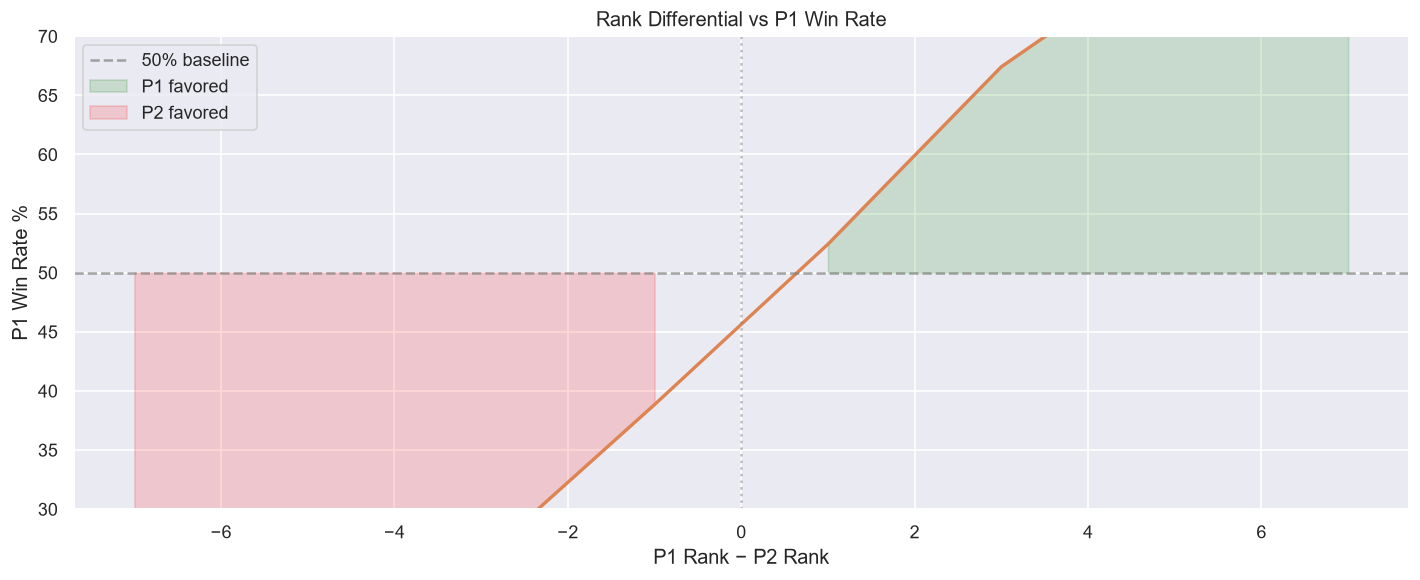

In [15]:
df['rank_diff'] = df['p1_rank'] - df['p2_rank']
df['rank_diff_bin'] = pd.cut(df['rank_diff'], bins=range(-30, 32, 2), right=False)
rank_signal = (
    df.groupby('rank_diff_bin', observed=True)['p1_won']
    .agg(['mean', 'count'])
    .reset_index()
)
rank_signal = rank_signal[rank_signal['count'] >= 200]
rank_signal['bin_center'] = rank_signal['rank_diff_bin'].apply(lambda x: x.mid)
rank_signal['win_pct']    = rank_signal['mean'] * 100

fig, ax = plt.subplots()
ax.plot(rank_signal['bin_center'], rank_signal['win_pct'], linewidth=2, color='#DD8452')
ax.axhline(50, color='gray', linestyle='--', alpha=0.7, label='50% baseline')
ax.axvline(0,  color='gray', linestyle=':',  alpha=0.5)
ax.fill_between(rank_signal['bin_center'], 50, rank_signal['win_pct'],
                where=rank_signal['win_pct'] > 50, alpha=0.15, color='green', label='P1 favored')
ax.fill_between(rank_signal['bin_center'], 50, rank_signal['win_pct'],
                where=rank_signal['win_pct'] < 50, alpha=0.15, color='red',   label='P2 favored')
ax.set_title('Rank Differential vs P1 Win Rate')
ax.set_xlabel('P1 Rank − P2 Rank')
ax.set_ylabel('P1 Win Rate %')
ax.set_ylim(30, 70)
ax.legend()
plt.tight_layout()
plt.show()

## 7 — Player History Depth

**What to look for:** To compute per-player features like recent win rate and character mastery, we need players with enough game history. Check what percentage of players have ≥20 games in the dataset.

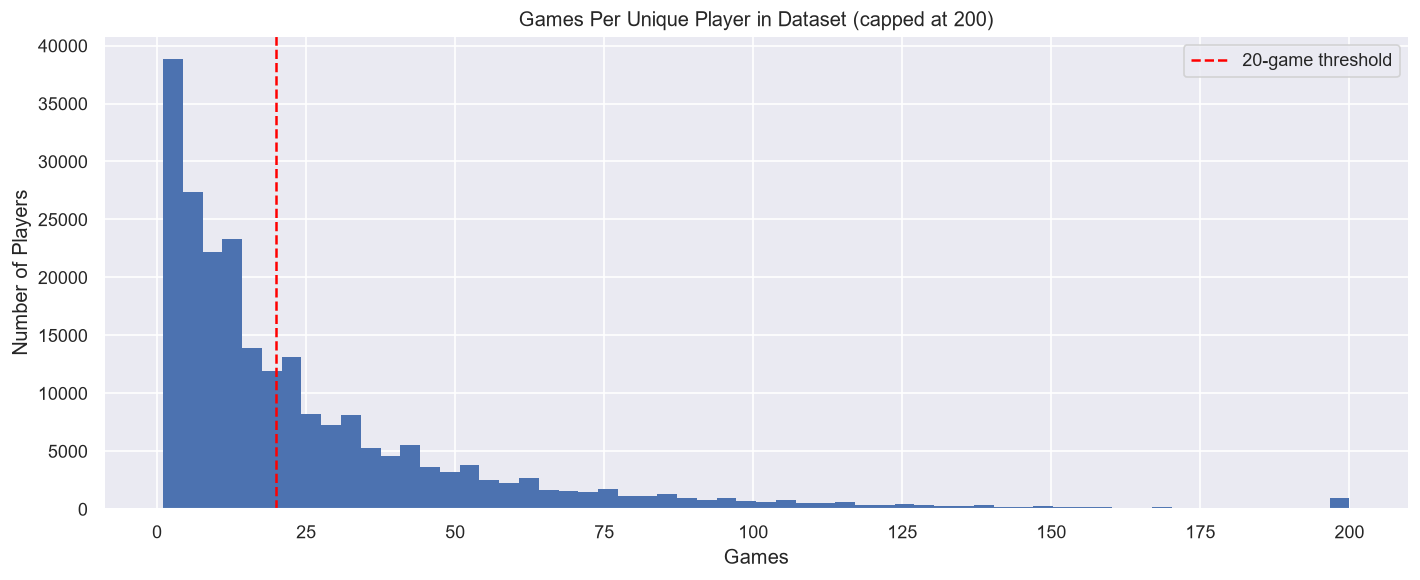

Total unique players: 229,547
  Players with ≥  5 games: 190,677 (83.1%)
  Players with ≥ 10 games: 148,014 (64.5%)
  Players with ≥ 20 games: 95,832 (41.7%)
  Players with ≥ 50 games: 34,164 (14.9%)
  Players with ≥100 games: 8,766 (3.8%)


In [16]:
all_polaris      = pd.concat([df['p1_polaris_id'], df['p2_polaris_id']])
games_per_player = all_polaris.value_counts()

fig, ax = plt.subplots()
ax.hist(games_per_player.clip(upper=200), bins=60, color='#4C72B0', edgecolor='none')
ax.axvline(20, color='red', linestyle='--', linewidth=1.5, label='20-game threshold')
ax.set_title('Games Per Unique Player in Dataset (capped at 200)')
ax.set_xlabel('Games')
ax.set_ylabel('Number of Players')
ax.legend()
plt.tight_layout()
plt.show()

total_players = len(games_per_player)
print(f'Total unique players: {total_players:,}')
for t in [5, 10, 20, 50, 100]:
    n = (games_per_player >= t).sum()
    print(f'  Players with ≥{t:3d} games: {n:,} ({n/total_players*100:.1f}%)')

## 8 — Summary Diagnostic

Run this cell last. It prints a quick OK/!! report across all key signals.

In [17]:
print('=' * 55)
print('  DATASET DIAGNOSTIC SUMMARY')
print('=' * 55)

print(f'\nTotal records      : {len(df):,}')
print(f'Unique players     : {total_players:,}')
print(f'Date range         : {df["battle_at"].min().date()} → {df["battle_at"].max().date()}')

p1w_pct    = df['p1_won'].mean() * 100
balance_ok = abs(p1w_pct - 50) < 2
print(f'\n[{"OK" if balance_ok else "!!"}] Class balance    : P1 wins {p1w_pct:.2f}% ({"balanced" if balance_ok else "IMBALANCED — investigate"})')

sparse_chars = char_counts[char_counts['count'] < 1000]
print(f'[{"OK" if sparse_chars.empty else "!!"}] Sparse characters : {len(sparse_chars)} chars with <1,000 appearances')

players_20plus = (games_per_player >= 20).sum()
pct_20plus     = players_20plus / total_players * 100
history_ok     = pct_20plus > 20
print(f'[{"OK" if history_ok else "!!"}] History depth     : {pct_20plus:.1f}% of players have ≥20 games ({"viable" if history_ok else "may need more data"})')

high_null = null_pct[null_pct > 50]
print(f'[{"OK" if high_null.empty else "!!"}] High-null fields  : {list(high_null.index) if not high_null.empty else "none — all fields usable"}')

print('\n' + '=' * 55)

  DATASET DIAGNOSTIC SUMMARY

Total records      : 3,017,586
Unique players     : 229,547
Date range         : 2025-12-31 → 2026-05-31

[OK] Class balance    : P1 wins 50.08% (balanced)
[OK] Sparse characters : 0 chars with <1,000 appearances
[OK] History depth     : 41.7% of players have ≥20 games (viable)
[OK] High-null fields  : none — all fields usable

